<a href="https://colab.research.google.com/github/Alina-Smol/portfolio_data_analyst/blob/main/%D0%BF%D0%BE%D1%80%D1%82%D1%84%D0%BE%D0%BB%D0%B8%D0%BE_%D0%BC%D0%BE%D0%B1%D0%B8%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9_%D0%BE%D0%BF%D0%B5%D1%80%D0%B0%D1%82%D0%BE%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Какие задачи поставлены:**
1. Описать поведение клиентов оператора, исходя из выборки по месячной статистики
2. Сколько минут разговора, сколько сообщений и какой объём интернет-трафика требуется пользователям каждого тарифа
в месяц?
3. Посчитать среднее количество, дисперсию и стандартное отклонение
4. Построит гистограммы.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np

In [ ]:
# выгрузка датасетов
users = pd.read_csv('https://code.s3.yandex.net/datasets/users.csv')
calls = pd.read_csv('https://code.s3.yandex.net/datasets/calls.csv')
messages = pd.read_csv('https://code.s3.yandex.net/datasets/messages.csv')
internet = pd.read_csv('https://code.s3.yandex.net/datasets/internet.csv', index_col=0)
tariffs = pd.read_csv('https://code.s3.yandex.net/datasets/tariffs.csv')

Работаем с таблицей пользователей

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# подсчёт пропусков
users.isna().sum()

,0
user_id,0
age,0
churn_date,462
city,0
first_name,0
last_name,0
reg_date,0
tariff,0


- user_id — уникальный идентификатор пользователя
- first_name — имя пользователя
- last_name — фамилия пользователя
- age — год рождения пользователя
- reg_date — дата подключения тарифа (день, месяц, год)
- churn_date — дата прекращения пользования тарифом (если значение пропущено, то тариф ещё действовал на момент выгрузки данных)
- city — город проживания пользователя
- tarif — название тарифного плана

In [ ]:
users['churn_date'] = pd.to_datetime(users['churn_date'], format="%Y-%m-%d")
users['reg_date'] = pd.to_datetime(users['reg_date'], format="%Y-%m-%d")

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


Таблица со звонками

In [ ]:
calls.head()

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


In [ ]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


In [ ]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format="%Y-%m-%d")
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  float64       
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.2+ MB


Таблица с сообщениями

In [ ]:
messages.head()
messages['message_date'] = pd.to_datetime(messages['message_date'], format="%Y-%m-%d")
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


In [ ]:
messages.head()

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [ ]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


Таблица с интернетом

In [ ]:
internet.head()

,id,mb_used,session_date,user_id
0,1000_0,112.95,2018-11-25,1000
1,1000_1,1052.81,2018-09-07,1000
2,1000_2,1197.26,2018-06-25,1000
3,1000_3,550.27,2018-08-22,1000
4,1000_4,302.56,2018-09-24,1000


In [ ]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149396 entries, 0 to 149395
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            149396 non-null  object 
 1   mb_used       149396 non-null  float64
 2   session_date  149396 non-null  object 
 3   user_id       149396 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 5.7+ MB


In [ ]:
internet['session_date'] = pd.to_datetime(internet['session_date'], format="%Y-%m-%d")

Таблица с тарифами

In [ ]:
tariffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 260.0+ bytes


In [ ]:
tariffs

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


# Количество сделанных звонков и израсходованных минут разговора по месяцам

In [ ]:
calls['month'] = calls['call_date'].dt.month_name()
user_calls = calls.groupby(['user_id', 'month']).agg({'duration': 'sum', 'id': 'count'}).reset_index().rename(columns={'duration':'month_calls_duration','id':'calls_total_in_month'})
user_calls

,user_id,month,month_calls_duration,calls_total_in_month
0,1000,August,389.87,52
1,1000,December,312.98,46
2,1000,July,318.80,47
3,1000,June,158.90,43
4,1000,May,150.06,22
...,...,...,...,...
3169,1498,September,446.68,59
3170,1499,December,465.16,69
3171,1499,November,576.50,74
3172,1499,October,429.91,68


# Количество отправленных сообщений по месяцам

In [ ]:
messages['month'] = messages['message_date'].dt.month_name()

In [ ]:
user_messages = messages.groupby(['user_id', 'month']).agg({'id': 'count'}).reset_index().rename(columns={'id':'sms_total_in_month'})

# Объем израсходованного интернет-трафика по месяцам

In [ ]:
internet['month'] = internet['session_date'].dt.month_name()
internet_month = internet.groupby(['user_id', 'month']).agg({'mb_used': 'sum'}).reset_index().rename(columns={'mb_used':'mb_total_in_month'})

,user_id,month,mb_total_in_month
0,1000,August,14055.93
1,1000,December,9817.61
2,1000,July,14003.64
3,1000,June,23233.77
4,1000,May,2253.49
...,...,...,...
3198,1498,September,22134.41
3199,1499,December,13055.58
3200,1499,November,17963.31
3201,1499,October,17788.51


# Месячная выручка с каждого пользователя

In [ ]:
df = user_calls.merge(user_messages, on=['user_id', 'month'], how='outer')
df = df.merge(internet_month, on=['user_id','month'], how = 'outer')
df = df.merge(users, on='user_id', how='left').rename(columns={'tariff':'tariff_name'})
df = df.merge(tariffs, on='tariff_name', how='left')
df

,user_id,month,month_calls_duration,calls_total_in_month,sms_total_in_month,mb_total_in_month,age,churn_date,city,first_name,last_name,reg_date,tariff_name,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute
0,1000,August,389.87,52.0,81.0,14055.93,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000,30720,3000,1950,150,1,1
1,1000,December,312.98,46.0,70.0,9817.61,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000,30720,3000,1950,150,1,1
2,1000,July,318.80,47.0,75.0,14003.64,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000,30720,3000,1950,150,1,1
3,1000,June,158.90,43.0,60.0,23233.77,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000,30720,3000,1950,150,1,1
4,1000,May,150.06,22.0,22.0,2253.49,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,1000,30720,3000,1950,150,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3209,1498,September,446.68,59.0,44.0,22134.41,68,2018-10-25,Владикавказ,Всеволод,Акимчин,2018-07-19,smart,50,15360,500,550,200,3,3
3210,1499,December,465.16,69.0,66.0,13055.58,35,NaT,Пермь,Гектор,Корнилов,2018-09-27,smart,50,15360,500,550,200,3,3
3211,1499,November,576.50,74.0,59.0,17963.31,35,NaT,Пермь,Гектор,Корнилов,2018-09-27,smart,50,15360,500,550,200,3,3
3212,1499,October,429.91,68.0,48.0,17788.51,35,NaT,Пермь,Гектор,Корнилов,2018-09-27,smart,50,15360,500,550,200,3,3


In [ ]:
df.isna().sum()

,0
user_id,0
month,0
month_calls_duration,40
calls_total_in_month,40
sms_total_in_month,497
mb_total_in_month,11
age,0
churn_date,3027
city,0
first_name,0


In [ ]:
# заменяем пустые ячейки 0, так будем вести поддсчет, что расход трафика равен нулю у пользователей
df['sms_total_in_month'] = df['sms_total_in_month'].fillna(0)
df['mb_total_in_month'] = df['mb_total_in_month'].fillna(0)
df['month_calls_duration'] = df['month_calls_duration'].fillna(0)
df['calls_total_in_month'] = df['calls_total_in_month'].fillna(0)

In [ ]:
df.isna().sum()

,0
user_id,0
month,0
month_calls_duration,0
calls_total_in_month,0
sms_total_in_month,0
mb_total_in_month,0
age,0
churn_date,3027
city,0
first_name,0


In [ ]:
# проверка на дубликаты
df.duplicated().sum()

np.int64(0)

- tariff_name — название тарифа
- rub_monthly_fee — ежемесячная абонентская плата в рублях
- minutes_included — количество минут разговора в месяц, включённых в абонентскую плату
- messages_included — количество сообщений в месяц, включённых в абонентскую плату
- mb_per_month_included — объём интернет-трафика, включённого в абонентскую плату (в мегабайтах)
- rub_per_minute — стоимость минуты разговора сверх тарифного пакета (например, если в тарифе 100 минут разговора в месяц, то со - 101 минуты будет взиматься плата)
- rub_per_message — стоимость отправки сообщения сверх тарифного пакета
- rub_per_gb — стоимость дополнительного гигабайта интернет-трафика сверх тарифного пакета (1 гигабайт = 1024 мегабайта)

In [ ]:
def revenu_from_users(row):
  sms = (row['sms_total_in_month'] - row['messages_included']) * row['rub_per_message']
  minutes = (row['month_calls_duration'] - row['minutes_included']) * row['rub_per_minute']
  mbs = np.floor((row['mb_total_in_month'] - row['mb_per_month_included']) * row['rub_per_gb'] / 1024)

  result = result = max(0, sms) + max(0, minutes) + max(0, mbs)
  return result



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                3214 non-null   int64         
 1   month                  3214 non-null   object        
 2   month_calls_duration   3214 non-null   float64       
 3   calls_total_in_month   3214 non-null   float64       
 4   sms_total_in_month     3214 non-null   float64       
 5   mb_total_in_month      3214 non-null   float64       
 6   age                    3214 non-null   int64         
 7   churn_date             187 non-null    datetime64[ns]
 8   city                   3214 non-null   object        
 9   first_name             3214 non-null   object        
 10  last_name              3214 non-null   object        
 11  reg_date               3214 non-null   datetime64[ns]
 12  tariff_name            3214 non-null   object        
 13  mes

In [ ]:
df['revenu_from_users'] = df.apply(lambda x: revenu_from_users(x), axis=1)
df['revenu_from_users']

,revenu_from_users
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
3209,1323.0
3210,48.0
3211,764.5
3212,474.0


In [ ]:
df['total_revenue'] = df['revenu_from_users'] + df['rub_monthly_fee']

In [ ]:
df.sort_values(by='total_revenue').tail()

,user_id,month,month_calls_duration,calls_total_in_month,sms_total_in_month,mb_total_in_month,age,churn_date,city,first_name,...,tariff_name,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,revenu_from_users,total_revenue
1817,1286,December,693.79,95.0,68.0,35108.07,19,NaT,Москва,Рашид,...,smart,50,15360,500,550,200,3,3,4492.37,5042.37
259,1042,December,680.16,121.0,75.0,37165.69,42,NaT,Хабаровск,Константин,...,smart,50,15360,500,550,200,3,3,4873.48,5423.48
3140,1486,November,723.39,108.0,96.0,36266.11,35,NaT,Нижний Новгород,Матвей,...,smart,50,15360,500,550,200,3,3,4891.17,5441.17
1645,1261,December,1015.89,141.0,22.0,32650.91,46,NaT,Казань,Мадина,...,smart,50,15360,500,550,200,3,3,4924.67,5474.67
3139,1486,December,954.70,133.0,83.0,38552.45,35,NaT,Нижний Новгород,Матвей,...,smart,50,15360,500,550,200,3,3,5992.10,6542.10


In [ ]:
df[['revenu_from_users', 'total_revenue']].describe()

,revenu_from_users,total_revenue
count,3214.000000,3214.000000
mean,482.600504,1461.660865
std,713.022756,777.891648
min,0.000000,550.000000
25%,0.000000,656.942500
50%,77.940000,1513.565000
75%,805.000000,1950.000000
max,5992.100000,6542.100000


In [ ]:
df['tariff_name'].value_counts()

,count
tariff_name,
smart,2229
ultra,985


<Axes: ylabel='Frequency'>

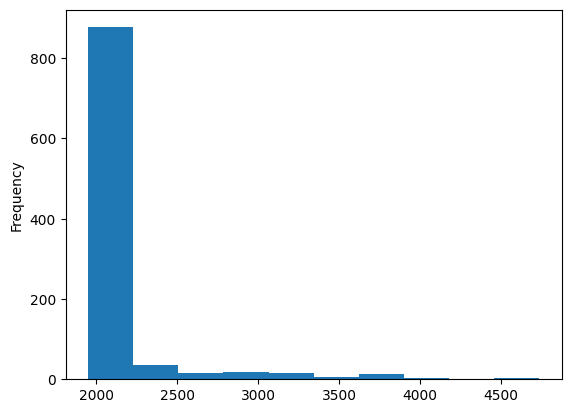

In [ ]:
df[df['tariff_name'] == 'ultra']['total_revenue'].plot(kind='hist', bins=10)

<Axes: ylabel='Frequency'>

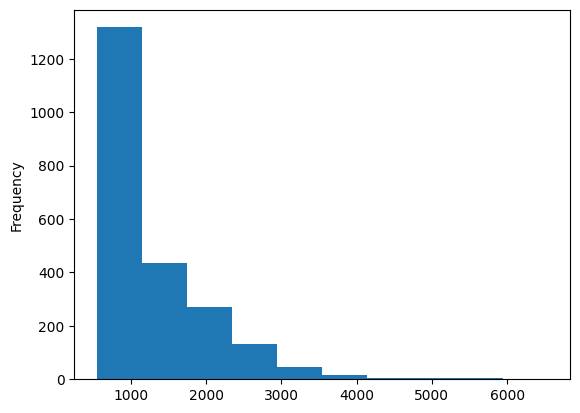

In [ ]:
df[df['tariff_name'] == 'smart']['total_revenue'].plot(kind='hist', bins=10)

In [ ]:
df.groupby('tariff_name')['total_revenue'].agg(['median','mean','var','std'])

,median,mean,var,std
tariff_name,,,,
smart,925.0,1197.341866,588992.010512,767.458149
ultra,1950.0,2059.800000,125843.213008,354.743870


ultra в основном платят по тарифурублей,а у smart люди не укладываются в абонентскую плату

Text(0.5, 1.0, 'Смарт — Звонки в минутах в месяц')

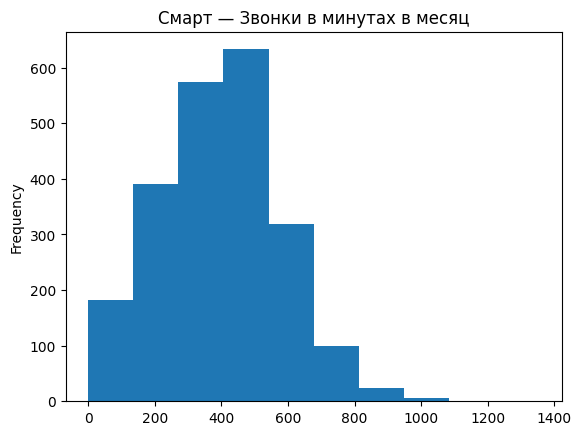

In [ ]:
df[df['tariff_name'] == 'smart']['month_calls_duration'].plot(kind='hist', bins=10)
plt.title('Смарт — Звонки в минутах в месяц')

Text(0.5, 1.0, 'Ultra — Звонки в минутах в месяц')

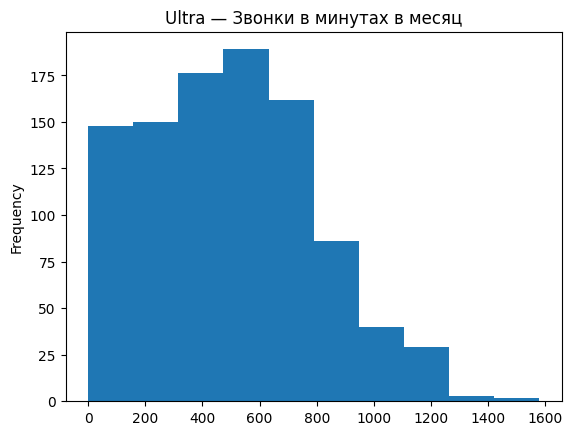

In [ ]:
df[df['tariff_name'] == 'ultra']['month_calls_duration'].plot(kind='hist', bins=10)
plt.title('Ultra — Звонки в минутах в месяц')

На Смарте больше всего людей говорят около 450 минут, на Ультре 550 минут в месяц. То есть на Смарте люди подходят к краю своего тарифа, а на Ультре у них остается запас 2450 минут